In [174]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [182]:
fid = {'Omega_m': 0.31, 'h': 0.67, 'log10As': 3.044, 'mu0': 0.0, 'sigma0': 0.0}

muq1_shear = {'std': {'Omega_m': 0.006, 'h': 0.006, 'log10As': 0.05, 'mu0': 0.2},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.01, 'h': 0.01, 'log10As': 0.08, 'mu0': 0.55},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.011, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.35},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

muq1_3x2pt= {'std': {'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
        'mean': {'Omega_m': 0.3105, 'h': 0.675, 'log10As': 3.046, 'mu0': 0.01, 'sigma0':0.},
        'err_minus': {'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
        'err_plus':{'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
}


mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.012, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.2},
        'mean': {'Omega_m': 0.3105, 'h': 0.675, 'log10As': 3.046, 'mu0': 0.01, 'sigma0':0.},
}


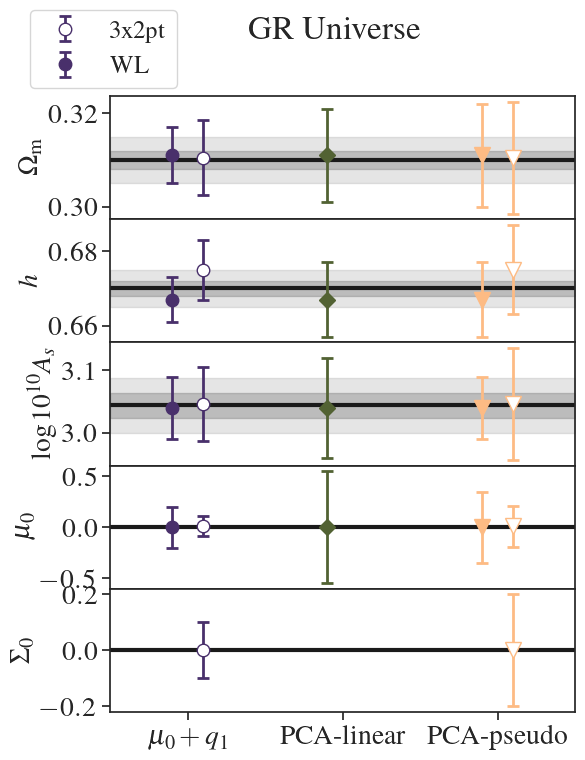

In [183]:
fig, ax = plt.subplots(5, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
colors = ['#49306B', '#526233', '#fdbb84']
#colors = ['#7f0000', '#e34a33', '#fdbb84']
style_muq1 = dict(fmt='o', markersize=9, markeredgecolor=colors[0], markerfacecolor=colors[0],
                 ecolor=colors[0], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcalin = dict(fmt='D', markersize=8, markeredgecolor=colors[1], markerfacecolor=colors[1],
                    ecolor=colors[1], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcapseudo = dict(fmt='v', markersize=11, markeredgecolor=colors[2], markerfacecolor=colors[2],
                       ecolor=colors[2], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')

style_muq1_3x2pt = dict(fmt='o', markersize=9, markeredgecolor=colors[0], markerfacecolor='white',
                 ecolor=colors[0], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcalin_3x2pt = dict(fmt='D', markersize=8, markeredgecolor=colors[1], markerfacecolor='white',
                    ecolor=colors[1], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcapseudo_3x2pt = dict(fmt='v', markersize=11, markeredgecolor=colors[2], markerfacecolor='white',
                       ecolor=colors[2], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')

shift=0.1


for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='-')
    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[[muq1_3x2pt['err_minus'][key]], [muq1_3x2pt['err_plus'][key]]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')


ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 1.8))
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.305, 0.315, color='tab:gray', alpha=0.2)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.308, 0.312, color='tab:gray', alpha=0.4)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.665, 0.675, color='tab:gray', alpha=0.2)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.668, 0.672, color='tab:gray', alpha=0.4)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3., 3.088, color='tab:gray', alpha=0.2)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3.024, 3.064, color='tab:gray', alpha=0.4)
ax[0].set_xlim(0.5, 3.5)
fig.suptitle("GR Universe")
plt.show()

In [184]:
muq1_shear = {'std': {'Omega_m': 0.005, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.08},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.1, 'mu0': 0.5},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.012, 'h': 0.015, 'log10As': 0.08, 'mu0': 0.22},
        'mean': {'Omega_m': 0.317, 'h': 0.66, 'log10As': 3.12, 'mu0': 0.15},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.018, 'h': 0.02, 'log10As': 0.05, 'mu0': 0.16},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.1, 'mu0': 0.25},
}

muq1_3x2pt= {'std': {'Omega_m': 0.01, 'h': 0.02, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.05, 'mu0': 0.5, 'sigma0':0.},
}


mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.02, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.05, 'mu0': 0.25, 'sigma0':0.},
}


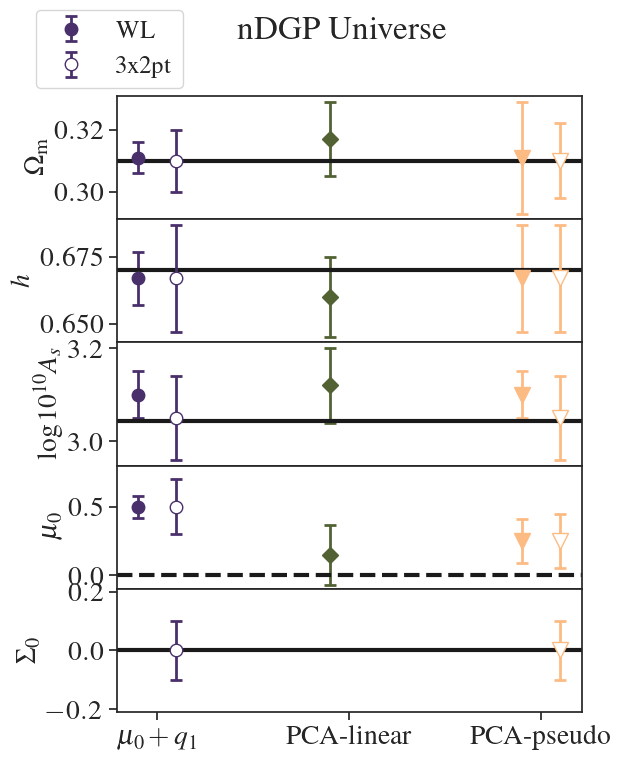

In [185]:
fig, ax = plt.subplots(5, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
shift=0.1

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')

for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='--' if i==3 else '-')
    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[muq1_3x2pt['std'][key]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
#    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 1.8))
ax[3].set_ylim(-0.1, 0.8)
ax[4].set_ylim(-0.21, 0.21)
fig.suptitle("nDGP Universe")
plt.show()

In [186]:
muq1_shear = {'std': {'Omega_m': 0.005, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.25},
        'mean': {'Omega_m': 0.3, 'h': 0.72, 'log10As': 2.8, 'mu0': 0.5},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.012, 'h': 0.015, 'log10As': 0.1, 'mu0': 0.5},
        'mean': {'Omega_m': 0.312, 'h': 0.67, 'log10As': 3., 'mu0': 0.},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.015, 'h': 0.02, 'log10As': 0.05, 'mu0': 0.25},
        'mean': {'Omega_m': 0.3, 'h': 0.72, 'log10As': 2.9, 'mu0': 0.5},
}

fofr_pcapseudo_shear = {'std': {'Omega_m': 0.015, 'h': 0.02, 'log10As': 0.1, 'log10fofr': 0.5},
        'mean': {'Omega_m': 0.31, 'h': 0.67, 'log10As': 3.044, 'log10fofr': -5},
}

# muq1_3x2pt bi-modal

mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.04, 'log10As': 0.1, 'mu0': 0.25, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.5, 'sigma0':0.},
}

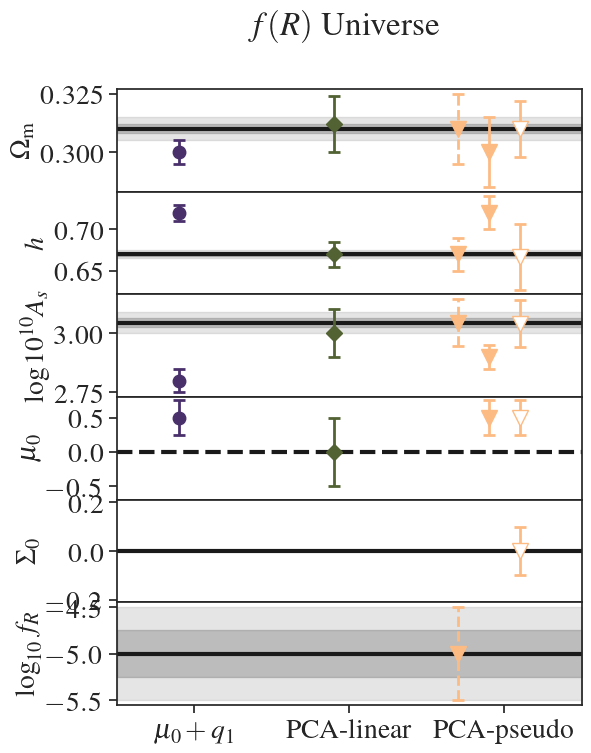

In [187]:
fig, ax = plt.subplots(6, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
shift=0.1
for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='--' if i==3 else '-')
#    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[muq1_3x2pt['std'][key]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
#    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')

for i in range(3):
    key = list(fid.keys())[i]
    eb3 = ax[i].errorbar([3-shift*3], [fofr_pcapseudo_shear['mean'][key]], yerr=[fofr_pcapseudo_shear['std'][key]], **style_pcapseudo)
    for barcol in eb3[2]:
            barcol.set_linestyle('--')
eb4 = ax[5].errorbar([3-shift*3], [fofr_pcapseudo_shear['mean']['log10fofr']], yerr=[fofr_pcapseudo_shear['std']['log10fofr']], **style_pcapseudo)
for barcol in eb4[2]:
            barcol.set_linestyle('--')
ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[5].set_ylabel("$\log_{10}f_R$")
#ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 2.))
ax[3].set_ylim(-0.7, 0.8)
ax[4].set_ylim(-0.21, 0.21)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.305, 0.315, color='tab:gray', alpha=0.2)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.308, 0.312, color='tab:gray', alpha=0.4)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.665, 0.675, color='tab:gray', alpha=0.2)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.668, 0.672, color='tab:gray', alpha=0.4)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3., 3.088, color='tab:gray', alpha=0.2)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3.024, 3.064, color='tab:gray', alpha=0.4)
ax[5].axhline(-5, color='k', linestyle='-')
ax[5].fill_between(np.linspace(0.5, 3.5,10), -5.5, -4.5, color='tab:gray', alpha=0.2)
ax[5].fill_between(np.linspace(0.5, 3.5,10), -5.25, -4.75, color='tab:gray', alpha=0.4)
ax[0].set_xlim(0.5, 3.5)
fig.suptitle("$f(R)$ Universe")
plt.show()

In [188]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

with open("tutorials/params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

with open("ini_files/pca/params_data.yaml", "r") as file:
    fiducials = yaml.safe_load(file)

def read_last_header_line(file_path):
    last_header = None
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.startswith('#'):
                last_header = line.strip('#').strip()  
            else:
                break  

    if last_header:
        return last_header.split() 
    else:
        return []

def read_chains(file_paths):
    n_samples = len(file_paths)
    chains_info = {}
    for i in range(n_samples):
        file_path = file_paths[i]  
        chain = np.genfromtxt(file_path)
        chain_pars = read_last_header_line(file_path)
        chain_pars = chain_pars[:-2]
        chains_info[i] = {}
        chains_info[i]['chain'] = chain
        chains_info[i]['pars'] = chain_pars


    samples = []    
    for i in range(n_samples):
        samples.append(
            getdist.MCSamples(samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                                        names = [i for i in chains_info[i]['pars']],
                                        weights=np.exp(chains_info[i]['chain'][:, -2]),
                                        labels = [params_dic[p]
                                                    for p in chains_info[i]['pars']],
                                        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                                        ) 
        )
    return chains_info, samples

In [189]:
file_paths = ['chains/pca_runs/chain_lsst_y1_test_fofR_linps_pca_gr_fofr_ndgp.txt',
'chains/chain_lsst_y1_test_fofR_nonlinps.txt']  
chains_info, samples = read_chains(file_paths)
ModelPars = chains_info[0]['pars']
ModelPars

Removed no burn in
Removed no burn in


['Omega_m', 'log10As', 'log10f_R0']

In [190]:
samples[0].getLatex(limit=1)

(['\\Omega_{\\rm m}', '\\log{10^{10}A_{\\rm s}}', '\\log_{10}{f_{\\rm R0}}'],
 ['0.3130^{+0.0068}_{-0.0061}', '3.024\\pm 0.040', '-5.64\\pm 0.77'])

In [191]:
fofr_pcalin_shear = {'means': {}, 'err_minus': {}, 'err_plus': {}}
margeStats = samples[0].getMargeStats()
for par in ModelPars:
    fofr_pcalin_shear['means'][par] = margeStats.parWithName(par).mean
    fofr_pcalin_shear['err_minus'][par] = fofr_pcalin_shear['means'][par]-margeStats.parWithName(par).limits[0].lower
    fofr_pcalin_shear['err_plus'][par] = margeStats.parWithName(par).limits[1].upper-fofr_pcalin_shear['means'][par]

fofr_pcalin_shear

{'means': {'Omega_m': 0.31298413298889693,
  'log10As': 3.02439272376017,
  'log10f_R0': -5.638320104162974},
 'err_minus': {'Omega_m': 0.0060587112343358784,
  'log10As': 0.038748579037207076,
  'log10f_R0': 0.9104677103423393},
 'err_plus': {'Omega_m': 0.012227709871580894,
  'log10As': 0.07872522851890862,
  'log10f_R0': 1.2995414563737633}}